# Experiment I — Gibbs Softmax Map

This notebook contains the three parts of Experiment I. Experiment I(a) studies how portfolio performance changes with signal strength, Experiment I(b) studies how the preferred strength changes with signal quality, and Experiment I(c) introduces correlation between asset returns. All three parts use the Gibbs softmax map

$$
w_i(s,\beta)=\frac{e^{\beta s_i}}{\sum_{j=1}^{N}e^{\beta s_j}}.
$$

At $\beta=0$, the map gives equal weight. Increasing $\beta$ places progressively more weight on assets with larger signal scores while keeping every weight positive. The purpose of the experiment is to identify how far the portfolio should move from equal weight when its drift signal is imperfect. Numerical tables, figures, and supporting diagnostics are retained in the notebook; the detailed interpretation is provided in Chapter 3.

## Model and simulation design

Each asset follows a one-step geometric Brownian motion with simple return

$$
R_i=\exp\!\left[\left(\mu_i-\frac12\sigma_i^2\right)\Delta t+\sigma_i\sqrt{\Delta t}\,\phi_i\right]-1.
$$

In the baseline design, $N=20$, $\Delta t=1$, and all assets have volatility $\sigma_i=0.20$. Their drifts are redrawn in every Monte-Carlo replication from $\mu_i=\bar\mu+\sigma_\mu z_i$, with $\bar\mu=0.05$ and $\sigma_\mu=0.05$. The map observes the drift-tracking signal

$$
s_i=\mu_i+\sigma_\varepsilon\xi_i,
$$

where the signal-noise vector is independent of the vector of standardised Brownian increments. A clean signal therefore reveals the drift but not the realised return.

Portfolio performance is measured by the mean--variance certainty equivalent

$$
\mathrm{CE}_{MV}(P)=\mathbb E[P]-\frac{\gamma}{2}\operatorname{Var}(P),\qquad \gamma=5,
$$

reported in basis points relative to equal weight. The simulation uses $30{,}000$ replications and the population-variance convention. Common random numbers are reused across the strength grid, noise levels, and relevant correlation settings, so comparisons are paired rather than driven by different simulated markets.

In [22]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

N        = 20        # number of stocks
dt       = 1.0       # one step of one year
sigma    = 0.20      # diffusion volatility, common to all names
mu_bar   = 0.05      # cross-sectional mean of the drifts
sigma_mu = 0.05      # cross-sectional dispersion of the drifts
gamma    = 5.0       # mean--variance risk coefficient
n_sims   = 30_000    # Monte-Carlo replications

beta_grid = np.linspace(0.0, 120.0, 121)   # step 1; peaks sit around 1/sigma_mu = 20

mu   = mu_bar + sigma_mu * rng.standard_normal((n_sims, N))   # drifts, redrawn each replication
eps0 = rng.standard_normal((n_sims, N))                       # standardised signal noise
phi  = rng.standard_normal((n_sims, N))                       # standardised Brownian increments

R = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi) - 1.0


In [23]:
def softmax_weights(s, beta):
    z = beta * s
    z -= z.max(axis=1, keepdims=True)
    e = np.exp(z)
    return e / e.sum(axis=1, keepdims=True)

def ce_mv(port):
    """Mean--variance certainty equivalent, with population (ddof=0) variance."""
    return port.mean() - 0.5 * gamma * port.var(ddof=0)

def mv_curve(sigma_eps, beta_grid=beta_grid):
    s = mu + sigma_eps * eps0
    CE = np.empty(len(beta_grid))
    for k, b in enumerate(beta_grid):
        w = softmax_weights(s, b)
        CE[k] = ce_mv((w * R).sum(axis=1))
    return CE

def mv_curve_R(R_mat, sigma_eps, beta_grid=beta_grid):
    s = mu + sigma_eps * eps0
    return np.array([ce_mv((softmax_weights(s, b) * R_mat).sum(axis=1)) for b in beta_grid])

def beta_star(beta_grid, CE):
    k = int(np.argmax(CE))
    return beta_grid[k], CE[k], k

def paired_block_ce(p_a, p_b, n_blocks=6):
    """Paired block estimate and Monte-Carlo SE of CE_MV(a)-CE_MV(b)."""
    vals = []
    for ix in np.array_split(np.arange(len(p_a)), n_blocks):
        vals.append(1e4 * (ce_mv(p_a[ix]) - ce_mv(p_b[ix])))
    vals = np.asarray(vals)
    return vals.mean(), vals.std(ddof=1) / np.sqrt(len(vals))


## Experiment I(a) — Strength sweep

The first experiment fixes signal noise at its baseline value $\sigma_\varepsilon=0.05$ and varies $\beta$ over the grid $\{0,1,\ldots,120\}$. For every value of $\beta$, the same signal and return draws are used to form portfolio weights and estimate $\Delta\mathrm{CE}_{MV}(\beta)$.

Increasing strength creates a trade-off. It raises exposure to assets with favourable drift scores, but it also concentrates the portfolio and increases variance. The code therefore searches for the grid value $\beta^*$ that maximises M--V CE rather than assuming that stronger tilting is always preferable. It reports the complete CE curve, the selected strength, the gain relative to equal weight, entropy deficit, concentration, and a block-based Monte-Carlo diagnostic.

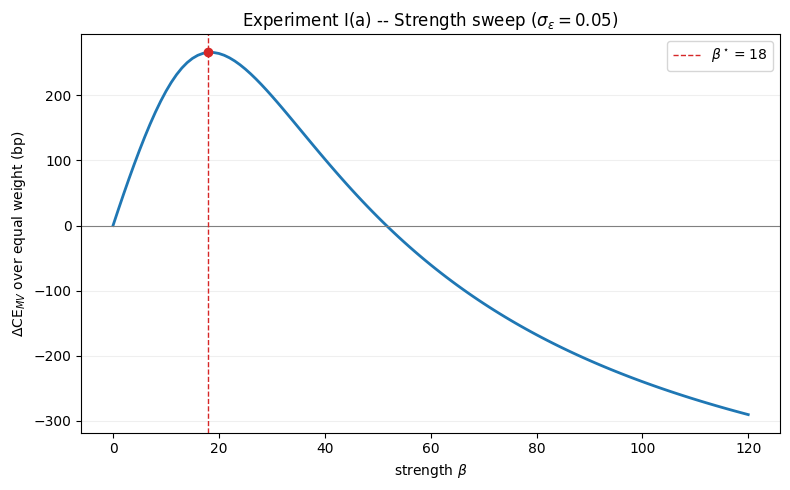

beta* = 18.0
CE_MV gain at beta*: 266.1 bp over equal weight
paired six-block MC SE of the gain: 5.6 bp


In [24]:
sigma_eps_base = 0.05

CE_b = mv_curve(sigma_eps_base)
bstar, ce_at_bstar, k = beta_star(beta_grid, CE_b)
dCE_b = CE_b - CE_b[0]

s_base = mu + sigma_eps_base * eps0
p_0 = (softmax_weights(s_base, 0.0) * R).sum(axis=1)
p_star = (softmax_weights(s_base, bstar) * R).sum(axis=1)
block_mean, se_dCE = paired_block_ce(p_star, p_0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(beta_grid, 1e4 * dCE_b, lw=2)
ax.axhline(0, color='grey', lw=0.8)
ax.axvline(bstar, color='tab:red', ls='--', lw=1, label=fr'$\beta^\star = {bstar:.0f}$')
ax.scatter([bstar], [1e4 * dCE_b[k]], color='tab:red', zorder=5)
ax.set_xlabel(r'strength $\beta$')
ax.set_ylabel(r'$\Delta$CE$_{MV}$ over equal weight (bp)')
ax.set_title(fr'Experiment I(a) -- Strength sweep ($\sigma_\varepsilon = {sigma_eps_base}$)')
ax.grid(axis='y', alpha=0.2); ax.legend()
plt.tight_layout(); plt.show()

print(f"beta* = {bstar:.1f}")
print(f"CE_MV gain at beta*: {1e4*dCE_b[k]:.1f} bp over equal weight")
print(f"paired six-block MC SE of the gain: {se_dCE:.1f} bp")


### Supporting P&L diagnostics

The following cell evaluates representative points on the strength path. It reports mean return, volatility, loss probability, downside quantiles, and paired performance relative to equal weight. These quantities support the CE comparison without replacing it as the selection criterion.

  beta     mean      vol  P(loss) 5%quantile  P(beat 1/N)  dCE (bp)
     0    5.28%    4.91%    14.0%   -2.63%           --       0.0
    18    9.44%    9.17%    13.5%   -3.94%        71.5%     266.1
    54   12.01%   17.33%    24.0%  -13.03%        64.4%     -18.1


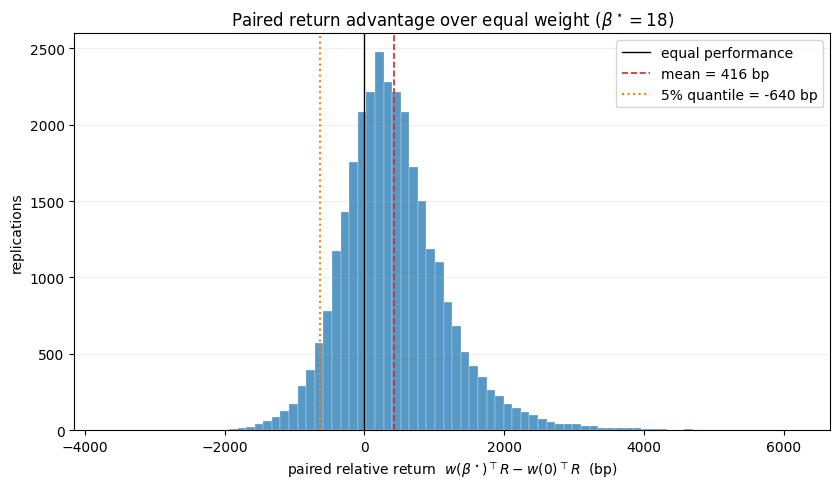

P(tilt beats 1/N) = 71.5%
mean relative return = 416 bp,  5% quantile = -640 bp


In [25]:
betas_show = [0.0, bstar, 3 * bstar]

ports, rows = {}, []
for b in betas_show:
    w = softmax_weights(s_base, b)
    p = (w * R).sum(axis=1)
    ports[b] = p
    ce = ce_mv(p)
    rows.append((b, p.mean(), p.std(ddof=1), (p < 0).mean(),
                 np.quantile(p, 0.05),
                 (p > ports[0.0]).mean() if b > 0 else np.nan,
                 1e4 * (ce - CE_b[0])))

print(f"{'beta':>6} {'mean':>8} {'vol':>8} {'P(loss)':>8} {'5%quantile':>8} {'P(beat 1/N)':>12} {'dCE (bp)':>9}")
for b, m, v, pl, q5, pb, dce in rows:
    pb_s = '          --' if np.isnan(pb) else f'{pb:>12.1%}'
    print(f"{b:>6.0f} {m:>8.2%} {v:>8.2%} {pl:>8.1%} {q5:>8.2%} {pb_s} {dce:>9.1f}")

d = ports[bstar] - ports[0.0]
q05_d = np.quantile(d, 0.05)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(1e4 * d, bins=80, color='tab:blue', alpha=0.75, edgecolor='white', linewidth=0.25)
ax.axvline(0, color='black', lw=1.0, label='equal performance')
ax.axvline(1e4 * d.mean(), color='tab:red', ls='--', lw=1.2,
           label=fr'mean = {1e4 * d.mean():.0f} bp')
ax.axvline(1e4 * q05_d, color='tab:orange', ls=':', lw=1.5,
           label=fr'5% quantile = {1e4 * q05_d:.0f} bp')
ax.set_xlabel(r'paired relative return  $w(\beta^\star)^\top R - w(0)^\top R$  (bp)')
ax.set_ylabel('replications')
ax.set_title(fr'Paired return advantage over equal weight ($\beta^\star = {bstar:.0f}$)')
ax.grid(axis='y', alpha=0.2)
ax.legend()
plt.tight_layout(); plt.show()

print(f"P(tilt beats 1/N) = {(d > 0).mean():.1%}")
print(f"mean relative return = {1e4 * d.mean():.0f} bp,  5% quantile = {1e4 * q05_d:.0f} bp")

## Experiment I(b) — Signal quality

The second experiment varies the signal-noise standard deviation over

$$
\sigma_\varepsilon\in\{0,0.01,0.025,0.05,0.10,0.20\}
$$

and re-optimises $\beta$ at every level. The underlying drifts, standard-normal signal-error draws, and realised returns remain fixed across the ladder; only the scale $\sigma_\varepsilon$ changes.

For the Gaussian drift model, the reliability coefficient is

$$
\kappa=\frac{\sigma_\mu^2}{\sigma_\mu^2+\sigma_\varepsilon^2}.
$$

This provides a benchmark for how quickly strength should fall as the signal becomes noisier. Because softmax is shift-invariant, shrinking the centred signal rescales its effective strength. The experiment nevertheless selects $\beta$ by portfolio CE, so the reliability curve is treated as a benchmark rather than imposed as the optimal rule. The output records the optimal strength, peak CE gain, and diagnostic portfolio statistics for every noise level.

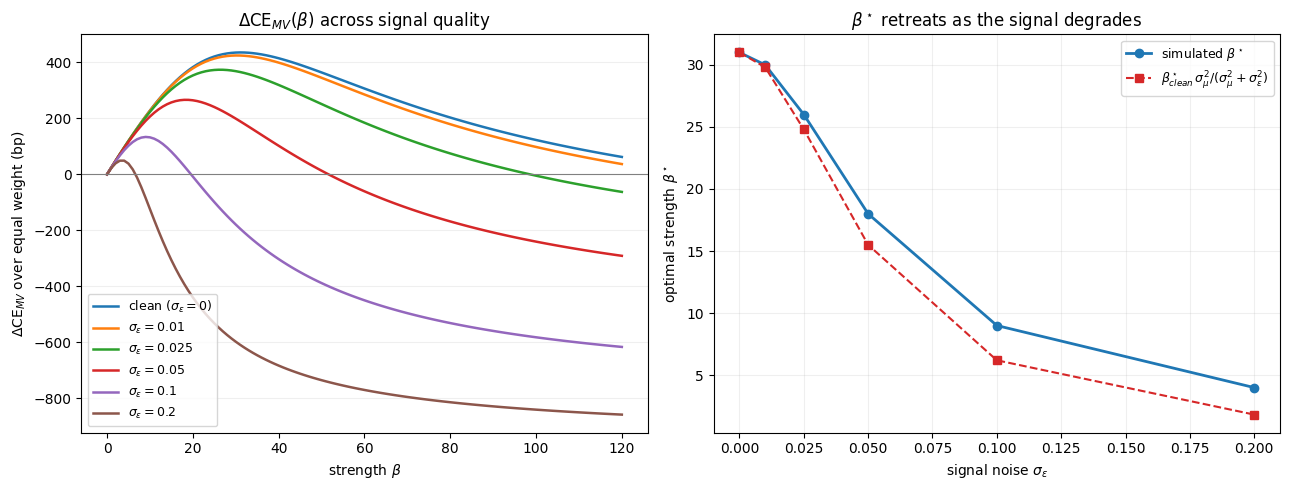

 sigma_eps    beta*  shrinkage pred.  peak dCE_MV (bp)
       0.0       31               31             435.3
      0.01       30               30             424.4
     0.025       26               25             373.6
      0.05       18               16             266.1
       0.1        9                6             133.6
       0.2        4                2              49.0


In [26]:
sigma_eps_levels = [0.0, 0.01, 0.025, 0.05, 0.10, 0.20]
results = {se: mv_curve(se) for se in sigma_eps_levels}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ax = axes[0]
for se in sigma_eps_levels:
    CE = results[se]
    label = 'clean ($\\sigma_\\varepsilon=0$)' if se == 0 else fr'$\sigma_\varepsilon={se}$'
    ax.plot(beta_grid, 1e4 * (CE - CE[0]), lw=1.8, label=label)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel(r'strength $\beta$'); ax.set_ylabel(r'$\Delta$CE$_{MV}$ over equal weight (bp)')
ax.set_title(r'$\Delta$CE$_{MV}(\beta)$ across signal quality')
ax.grid(axis='y', alpha=0.2); ax.legend(fontsize=9)

bstars = np.array([beta_star(beta_grid, results[se])[0] for se in sigma_eps_levels])
kappa  = sigma_mu**2 / (sigma_mu**2 + np.array(sigma_eps_levels)**2)
pred   = bstars[0] * kappa
ax = axes[1]
ax.plot(sigma_eps_levels, bstars, 'o-', lw=2, label=r'simulated $\beta^\star$')
ax.plot(sigma_eps_levels, pred, 's--', lw=1.5, color='tab:red',
        label=r'$\beta^\star_{clean}\,\sigma_\mu^2/(\sigma_\mu^2+\sigma_\varepsilon^2)$')
ax.set_xlabel(r'signal noise $\sigma_\varepsilon$'); ax.set_ylabel(r'optimal strength $\beta^\star$')
ax.set_title(r'$\beta^\star$ retreats as the signal degrades')
ax.grid(alpha=0.2); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'sigma_eps':>10} {'beta*':>8} {'shrinkage pred.':>16} {'peak dCE_MV (bp)':>17}")
for se, bs, pr in zip(sigma_eps_levels, bstars, pred):
    CE = results[se]
    print(f"{se:>10} {bs:>8.0f} {pr:>16.0f} {1e4*(CE.max()-CE[0]):>17.1f}")


### Clean-versus-noisy diagnostic

This cell compares clean and noisy signals on the same Monte-Carlo draws. It separates the performance loss caused by signal noise from ordinary sampling variation and reports paired differences at their respective CE-optimal strengths.

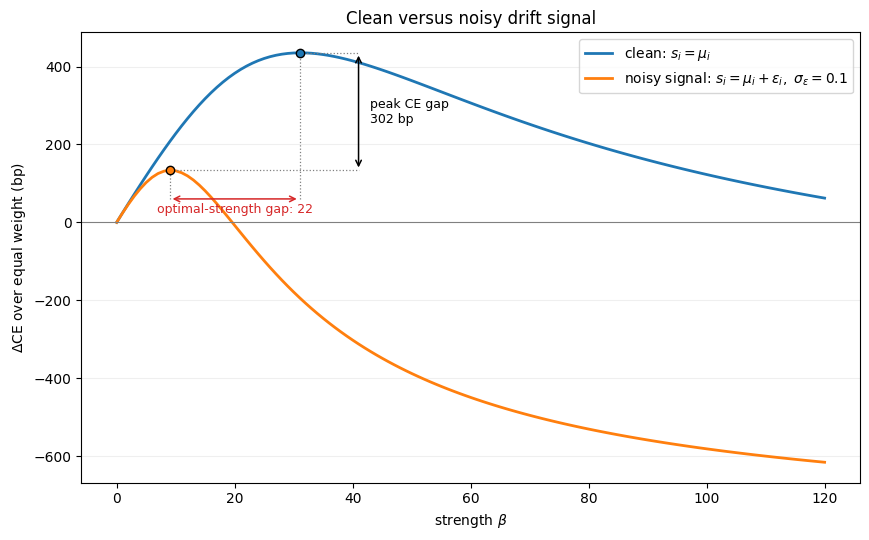

clean : beta* = 31, peak gain = 435.3 bp
noisy signal: beta* = 9, peak gain = 133.6 bp
difference between peak CE gains = 301.7 bp
optimal-strength gap = 22


In [27]:
se_noisy = 0.10
CE_or = results[0.0]
CE_no = results[se_noisy]
d_or, d_no = 1e4 * (CE_or - CE_or[0]), 1e4 * (CE_no - CE_no[0])

b_or, _, k_or = beta_star(beta_grid, CE_or)
b_no, _, k_no = beta_star(beta_grid, CE_no)

fig, ax = plt.subplots(figsize=(8.8, 5.5))
clean_color, noisy_color = 'tab:blue', 'tab:orange'
ax.plot(beta_grid, d_or, lw=2, color=clean_color, label=r'clean: $s_i=\mu_i$')
ax.plot(beta_grid, d_no, lw=2, color=noisy_color,
        label=fr'noisy signal: $s_i=\mu_i+\varepsilon_i,\ \sigma_\varepsilon={se_noisy}$')
ax.axhline(0, color='grey', lw=0.8)
ax.scatter(b_or, d_or[k_or], color=clean_color, edgecolor='black', zorder=5)
ax.scatter(b_no, d_no[k_no], color=noisy_color, edgecolor='black', zorder=5)

x_gap = b_or + 10
ax.hlines(d_or[k_or], b_or, x_gap, colors='grey', linestyles=':', lw=0.9)
ax.hlines(d_no[k_no], b_no, x_gap, colors='grey', linestyles=':', lw=0.9)
ax.annotate('', xy=(x_gap, d_no[k_no]), xytext=(x_gap, d_or[k_or]),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.1))
ax.text(x_gap + 2, 0.5 * (d_no[k_no] + d_or[k_or]),
        f'peak CE gap\n{d_or[k_or] - d_no[k_no]:.0f} bp', va='center', fontsize=9)

y_gap = 0.45 * d_no[k_no]
ax.vlines([b_no, b_or], y_gap, [d_no[k_no], d_or[k_or]],
          colors='grey', linestyles=':', lw=0.9)
ax.annotate('', xy=(b_or, y_gap), xytext=(b_no, y_gap),
            arrowprops=dict(arrowstyle='<->', color='tab:red', lw=1.1))
ax.text(0.5 * (b_or + b_no), y_gap - 35,
        fr'optimal-strength gap: {b_or - b_no:.0f}',
        fontsize=9, ha='center', color='tab:red')
ax.set_xlabel(r'strength $\beta$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title('Clean versus noisy drift signal')
ax.grid(axis='y', alpha=0.2)
ax.legend()
plt.tight_layout(); plt.show()

print(f"clean : beta* = {b_or:.0f}, peak gain = {d_or[k_or]:.1f} bp")
print(f"noisy signal: beta* = {b_no:.0f}, peak gain = {d_no[k_no]:.1f} bp")
print(f"difference between peak CE gains = {d_or[k_or]-d_no[k_no]:.1f} bp")
print(f"optimal-strength gap = {b_or-b_no:.0f}")


## Experiment I(c) — Correlated assets

The first two parts use independent Brownian increments. Experiment I(c) introduces dependence between asset returns while leaving the drift-signal construction and all other baseline parameters unchanged.

The first specification is equicorrelation:

$$
\phi_i=\sqrt{\rho}\,Z_0+\sqrt{1-\rho}\,Z_i,
\qquad \rho\in\{0,0.25,0.5\},
$$

where $Z_0,Z_1,\ldots,Z_N$ are independent standard normal draws. Every pair of increments then has correlation $\rho$. For the Gaussian diffusion component of a fully invested portfolio,

$$
\operatorname{Var}(\sigma w^\top\phi)=\sigma^2\left[\rho+(1-\rho)\lVert w\rVert^2\right].
$$

The first term is common to all fully invested portfolios, while the second depends on concentration. The formula provides the mechanism being tested, although the reported CE is calculated from simulated lognormal simple returns.

The second specification uses a seed-fixed three-factor structure. Its first factor has positive but heterogeneous loadings, while the remaining factors permit loadings of either sign. This produces heterogeneous pairwise correlations, including some negative values. The strength sweep is repeated under every covariance structure, with the $\rho=0$ equicorrelation case reproducing the independent baseline as an implementation check.

factor-model correlations: mean 0.16, min -0.21, max 0.57



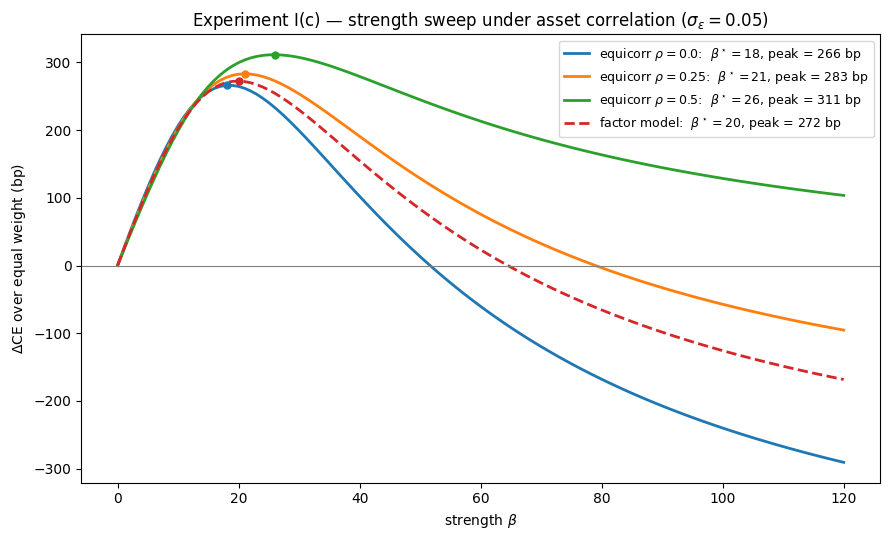

              case  avg corr   beta*  peak dCE (bp)  CE(0) level
      equicorr rho=0.0      0.00      18          266.1       0.0468
     equicorr rho=0.25      0.25      21          283.2       0.0202
      equicorr rho=0.5      0.50      26          311.4      -0.0067
          factor model      0.16      20          272.5       0.0293


In [28]:
# (a) equicorrelation: phi_i = sqrt(rho) Z0 + sqrt(1-rho) Z_i
rho_levels = [0.0, 0.25, 0.5]

rng_corr = np.random.default_rng(4242)
z0 = rng_corr.standard_normal((n_sims, 1))          # common normal draw, shared across all rho

def mv_curve_R_local(R_mat, sigma_eps):
    return mv_curve_R(R_mat, sigma_eps)

res_corr = {}
for rho in rho_levels:
    phi_rho = np.sqrt(rho) * z0 + np.sqrt(1.0 - rho) * phi
    R_rho = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi_rho) - 1.0
    res_corr[fr'equicorr $\rho={rho}$'] = mv_curve_R_local(R_rho, sigma_eps_base)

# (b) random factor model: loadings drawn once (seed-fixed), heterogeneous correlations
k_fac = 3
rng_fac = np.random.default_rng(7)
B = np.empty((N, k_fac))
B[:, 0]  = 0.45 + 0.15 * rng_fac.standard_normal(N)        # market factor: positive, heterogeneous
B[:, 1:] = 0.30 * rng_fac.standard_normal((N, k_fac - 1))  # style factors: mixed signs
norms = np.sqrt((B**2).sum(axis=1))
too_big = norms > 0.95
B[too_big] *= (0.95 / norms[too_big])[:, None]              # keep idiosyncratic variance positive
idio = np.sqrt(1.0 - (B**2).sum(axis=1))

C_fac = B @ B.T
np.fill_diagonal(C_fac, 1.0)
off = C_fac[~np.eye(N, dtype=bool)]
print(f"factor-model correlations: mean {off.mean():.2f}, min {off.min():.2f}, max {off.max():.2f}\n")

F = rng_fac.standard_normal((n_sims, k_fac))                # factor increments
phi_fac = F @ B.T + phi * idio                              # baseline idiosyncratic increments reused
R_fac = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * phi_fac) - 1.0
res_corr['factor model'] = mv_curve_R_local(R_fac, sigma_eps_base)

fig, ax = plt.subplots(figsize=(9, 5.5))
for name, CE in res_corr.items():
    dCE = 1e4 * (CE - CE[0])
    bs, _, kk = beta_star(beta_grid, CE)
    ls = '--' if name == 'factor model' else '-'
    ax.plot(beta_grid, dCE, lw=2, ls=ls, label=fr'{name}:  $\beta^\star={bs:.0f}$, peak = {dCE[kk]:.0f} bp')
    ax.scatter([bs], [dCE[kk]], zorder=5, s=25)
ax.axhline(0, color='grey', lw=0.8)
ax.set_xlabel(r'strength $\beta$')
ax.set_ylabel(r'$\Delta$CE over equal weight (bp)')
ax.set_title(fr'Experiment I(c) — strength sweep under asset correlation ($\sigma_\varepsilon = {sigma_eps_base}$)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'case':>18} {'avg corr':>9} {'beta*':>7} {'peak dCE (bp)':>14} {'CE(0) level':>12}")
for name, CE in res_corr.items():
    bs, _, kk = beta_star(beta_grid, CE)
    avg = {'equicorr $\\rho=0.0$': 0.0, 'equicorr $\\rho=0.25$': 0.25,
           'equicorr $\\rho=0.5$': 0.5}.get(name, off.mean())
    clean_name = name.replace('$', '').replace('\\rho', 'rho')
    print(f"{clean_name:>22} {avg:>9.2f} {bs:>7.0f} {1e4*(CE[kk]-CE[0]):>14.1f} {CE[0]:>12.4f}")

## Methodology

All three parts use the same M--V CE estimator, baseline calibration, and common-random-number design. Strength optima are selected on explicit grids, and endpoint checks are used to distinguish an interior optimum from grid truncation. Headline comparisons include paired block diagnostics where sampling variation is relevant.

The correlation formula describes the Gaussian diffusion component rather than an exact variance decomposition of lognormal simple returns. Numerical levels therefore depend on the stated calibration, while the notebook is designed to test the direction and stability of the mechanisms under controlled changes in strength, signal noise, and return dependence.